# 02 Collect Sources

Collect and audit the dynamic source artifacts used by the Marshfield Event Catalog: CORA coastal water level, ERA5 ocean waves, direct AORC SST rainfall members, and NWM soil-moisture context.


> **Stage Contract**
>
> Requires: region setup outputs, data_sources.yaml, Earthdata credentials where required
>
> Produces: CORA, ERA5 waves, AORC SST rainfall, NWM soil-moisture source artifacts

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import design_events.collect_sources.workflow as collect


config, paths = collect.load_runtime(location_root / "config.yaml")
display(collect.summary(config, paths))


location                                                   marshfield
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

## Rerun Control


In [ ]:
rerun = False


## Source Collection Plan

In [2]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)


,source,start,end,will_reuse_existing,action
0,cora,1979-02-01,2022-12-31,True,reuse complete artifact
1,nwm,1979-02-01,2022-12-31,True,reuse complete artifact
2,aorc_sst,1979-02-01,2022-12-31,True,reuse complete artifact
3,era5_waves,1979-02-01,2022-12-31,True,reuse complete artifact
4,hurdat2,1979-02-01,2022-12-31,False,collect or repair


## CORA Coastal Water Level

CORA provides the historical boundary water-level series for Marshfield surge-event fitting. The downstream Event Catalog expects the hourly MSL CSV at `paths["waterlevel_csv"]`.


In [3]:
cora_path = paths["waterlevel_csv"]
if cora_path.exists():
    waterlevel = pd.read_csv(cora_path, parse_dates=["time"])
    display(pd.Series({"rows": len(waterlevel), "start": waterlevel["time"].min(), "end": waterlevel["time"].max(), "path": str(cora_path)}))
    display(waterlevel.head())
else:
    display(pd.Series({"status": "missing", "expected_path": str(cora_path)}))


rows                                                385681
start                                  1979-01-01 00:00:00
end                                    2022-12-31 00:00:00
path     /home/grahamhults/projects/Flood-RM/locations/...
dtype: object

,time,value
0,1979-01-01 00:00:00,-1.660526
1,1979-01-01 01:00:00,-1.154254
2,1979-01-01 02:00:00,-0.318566
3,1979-01-01 03:00:00,0.595984
4,1979-01-01 04:00:00,1.224257


## ERA5 Ocean Waves

Marshfield is wave-enabled. The configured Earth Data Hub ERA5 ocean-wave Zarr variables are staged into a local NetCDF for SnapWave/SFINCS coupling.

In [4]:
waves = config["collection"].get("era5_waves", {})
display(pd.Series({
    "provider": waves.get("provider"),
    "bbox_wgs84": waves.get("bbox_wgs84"),
    "output": str(paths["era5_waves_nc"]),
    "exists": paths["era5_waves_nc"].exists(),
}))


provider                                           earthdatahub
bbox_wgs84                           [-71.0, 42.0, -70.0, 42.5]
output        /home/grahamhults/projects/Flood-RM/locations/...
exists                                                     True
dtype: object

## Stochastic Storm Transposition Region

The SST region is the configured AORC SST transposition polygon, not a notebook-specific hand draw. For Marshfield, `config.yaml` points to the 100 km candidate region around the study grid footprint, chosen during the AORC homogeneity review so the rainfall catalogue samples plausible coastal New England storms without drifting into a much broader regional climate.


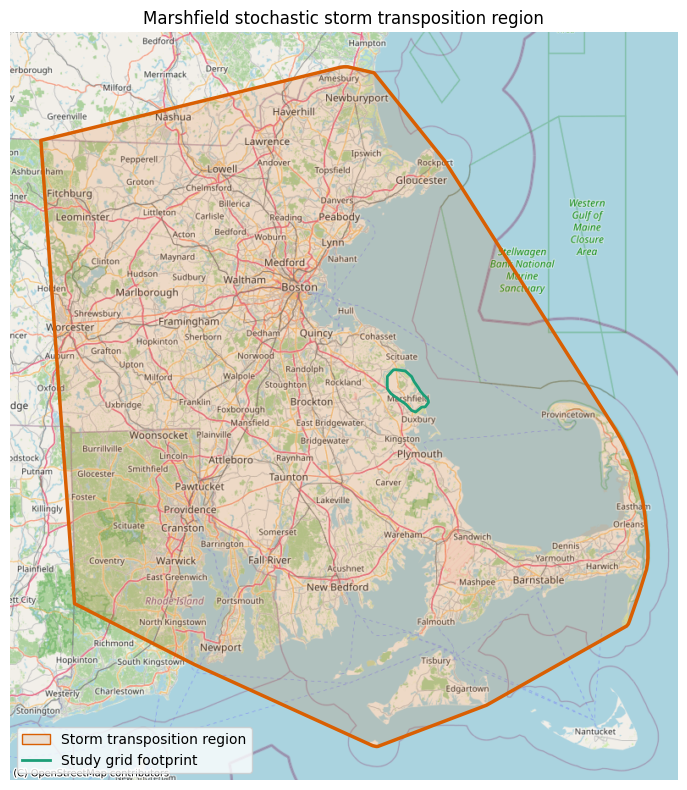

In [5]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
def _location_path(value):
    path = Path(value)
    if path.is_absolute():
        return path
    if path.parts and path.parts[0] in {"data", "02_flood", "01_grid"}:
        return paths["location_root"] / path
    return paths["repo_root"] / path


def plot_sst_region(config, paths, zoom=9, basemap=True):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    import contextily as ctx

    region_file = config["collection"]["aorc_sst"]["transposition_region"]["geometry_file"]
    footprint_file = config["grid_footprint"]["source"]
    region_path = _location_path(region_file)
    footprint_path = _location_path(footprint_file)

    region = gpd.read_file(region_path).to_crs("EPSG:4326")
    footprint = gpd.read_file(footprint_path).to_crs("EPSG:4326")
    region_web = region.to_crs(epsg=3857)
    footprint_web = footprint.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(8, 8))
    region_web.plot(ax=ax, facecolor="#d95f0226", edgecolor="#d95f02", linewidth=2.5)
    footprint_web.boundary.plot(ax=ax, color="#1b9e77", linewidth=2.0)

    xmin, ymin, xmax, ymax = region_web.total_bounds
    pad_x = (xmax - xmin) * 0.05
    pad_y = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    if basemap:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=zoom, attribution_size=7)

    ax.legend(
        handles=[
            Patch(facecolor="#d95f0226", edgecolor="#d95f02", label="Storm transposition region"),
            Line2D([0], [0], color="#1b9e77", linewidth=2.0, label="Study grid footprint"),
        ],
        loc="lower left",
    )
    ax.set_axis_off()
    ax.set_title("Marshfield stochastic storm transposition region")
    fig.tight_layout()
    return fig, ax


fig, ax = plot_sst_region(config, paths)


## Direct AORC SST Rainfall Members

The direct AORC SST collector scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table used to pair precipitation with synthetic coastal water-level events.


In [6]:
aorc_sst = config["collection"].get("aorc_sst", {})
display(pd.Series({
    "source": "direct_aorc_sst",
    "transposition_region": aorc_sst.get("transposition_region", {}).get("geometry_file"),
    "rainfall_members": str(paths["aorc_sst_rainfall_members_csv"]),
    "rainfall_members_exists": paths["aorc_sst_rainfall_members_csv"].exists(),
}))


source                                                       direct_aorc_sst
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
rainfall_members           /home/grahamhults/projects/Flood-RM/locations/...
rainfall_members_exists                                                 True
dtype: object

## NWM Soil-Moisture Context

Marshfield has no meaningful streamflow boundary in the baseline, but selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing.


In [7]:
display(collect.soil_sources(config, paths))


version                                                                                3.0
streamflow_available                                                                 False
streamflow_reason                        Marshfield coastal SFINCS grid has no meaningf...
soil_moisture_points                                                                     0
soil_moisture_variables                                              [SOIL_M, SOILSAT_TOP]
soil_moisture_zarr                       s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr...
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

## Run Collection

Run each configured source inside this notebook and show progress as each provider finishes. This cell is configured for the full Marshfield production collection window, so it overwrites partial smoke artifacts instead of reusing them.


In [8]:
# Collect configured sources and summarize the artifacts.
collection_parameters = pd.Series({
    "rerun": rerun,
    "skip_existing": not rerun,
    "sources": ", ".join(plan.source_names),
}, name="collection_run_parameters")
display(collection_parameters)

collection_result_table = collect.run_collect(
    config,
    paths,
    plan,
    run_collection=True,
    skip_existing=not rerun,
)
display(collection_result_table)


CORA water level: reusing /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/cora_waterlevel/cora_mfield_boundary_hourly_msl.csv (385,681 hourly rows, 1979-01-01 00:00:00 to 2022-12-31 00:00:00)
NWM: reusing complete production artifacts in /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/nwm
AORC SST: reusing complete rainfall catalog /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/aorc_sst/marshfield/72hr-events/ranked-storms.csv


ERA5 waves:   0%|          | 0/3 [00:00<?, ?stage/s]

ERA5 waves: reusing complete production artifact /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sources/era5_waves/era5_mfield_offshore_hourly.nc
ERA5 waves: validated 384,937 time steps and 4 variables


,source,status,duration_seconds,rows,artifact
0,cora,collected,0.42,385681,/home/grahamhults/projects/Flood-RM/locations/...
1,nwm,reused,3.93,2566240,/home/grahamhults/projects/Flood-RM/locations/...
2,aorc_sst,collected,0.16,440,/home/grahamhults/projects/Flood-RM/locations/...
3,era5_waves,collected,0.05,384937,/home/grahamhults/projects/Flood-RM/locations/...
4,hurdat2,reused,0.08,54749,/home/grahamhults/projects/Flood-RM/locations/...
5,rainfall_members,collected,0.00,440,/home/grahamhults/projects/Flood-RM/locations/...


## Readiness Audit

The readiness report records which artifacts are present and which source contracts still need attention before event-catalog construction.


In [9]:
readiness_summary, gates = collect.readiness_report(config, paths)
display(readiness_summary)
display(gates)


passed                                                False
report    /home/grahamhults/projects/Flood-RM/locations/...
Name: data_acquisition_readiness, dtype: object

,id,passed,issues,details
0,aorc_sst_collection,True,,"{'status': 'complete', 'storm_stats_rows': 636..."
1,rainfall_catalog,True,,"{'rainfall_member_rows': 440, 'event_catalog_r..."
2,source_acquisition,False,NWM soil moisture points are not configured,"{'rainfall_backend': 'aorc_sst', 'streamflow_a..."
3,wave_forcing,True,,"{'required': True, 'variables': ['swh', 'pp1d'..."


## Collected Data Overview

Plot the collected source data in the form that best matches each source: spatial footprints and sample points for geography, source-window bars for coverage, and time-series or distribution plots for the dynamic forcing records.


In [10]:
# Set up small plotting helpers.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _location_path(value):
    path = Path(value)
    if path.is_absolute():
        return path
    if path.parts and path.parts[0] in {"data", "02_flood", "01_grid"}:
        return paths["location_root"] / path
    return paths["repo_root"] / path


def _read_csv(path, **kwargs):
    path = Path(path)
    return pd.read_csv(path, **kwargs) if path.exists() else pd.DataFrame()


def _first_column(frame, names):
    return next((name for name in names if name in frame.columns), None)


### SST

Storm transposition targets are plotted against the configured SST region and study area.


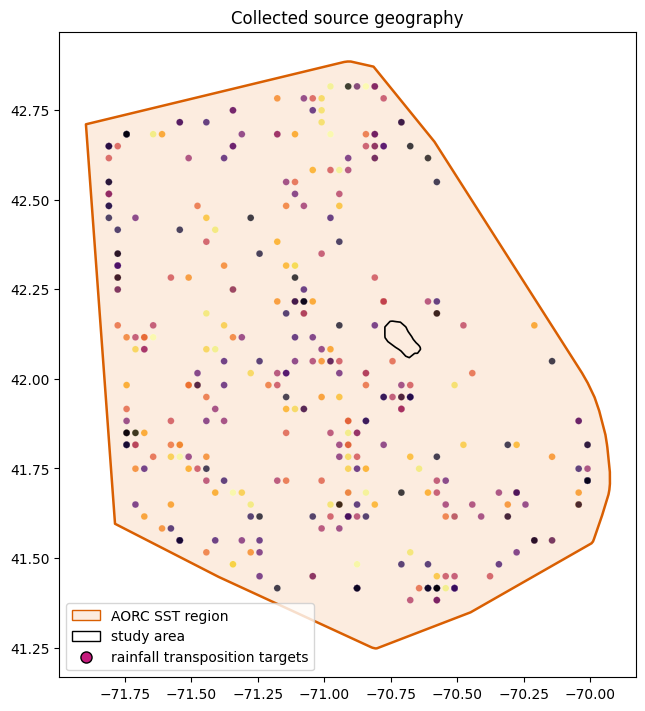

In [11]:
# Plot the SST region, study area, and rainfall transposition targets.
import geopandas as gpd

study_area = gpd.read_file(_location_path(config["grid_footprint"]["source"])).to_crs("EPSG:4326")
sst_region = gpd.read_file(
    _location_path(config["collection"]["aorc_sst"]["transposition_region"]["geometry_file"])
).to_crs("EPSG:4326")
rainfall = _read_csv(paths["aorc_sst_rainfall_members_csv"], parse_dates=["storm_start", "storm_end"])

lon_column = _first_column(rainfall, ["centroid_lon", "transposed_centroid_lon"])
lat_column = _first_column(rainfall, ["centroid_lat", "transposed_centroid_lat"])
value_column = _first_column(rainfall, ["max_precip_in", "mean_precip_in", "max", "mean"])

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
sst_region.plot(ax=ax, facecolor="#f4a26133", edgecolor="#d95f02", linewidth=1.8)
study_area.boundary.plot(ax=ax, color="black", linewidth=1.2)

if not rainfall.empty and lon_column and lat_column:
    rainfall_points = gpd.GeoDataFrame(
        rainfall.dropna(subset=[lon_column, lat_column]),
        geometry=gpd.points_from_xy(rainfall[lon_column], rainfall[lat_column]),
        crs="EPSG:4326",
    )
    rainfall_points.plot(
        ax=ax,
        column=value_column,
        cmap="inferno_r",
        markersize=24,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.15,
        legend=value_column is not None,
        legend_kwds={"label": "72h rainfall magnitude", "shrink": 0.62},
    )

ax.legend(
    handles=[
        Patch(facecolor="#f4a26133", edgecolor="#d95f02", label="AORC SST region"),
        Patch(facecolor="none", edgecolor="black", label="study area"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#c51b7d", markersize=8, label="rainfall transposition targets"),
    ],
    loc="best",
)
ax.set_title("Collected source geography")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


### CORA Boundary Water Level

Boundary water levels are plotted independently from the spatial source map.


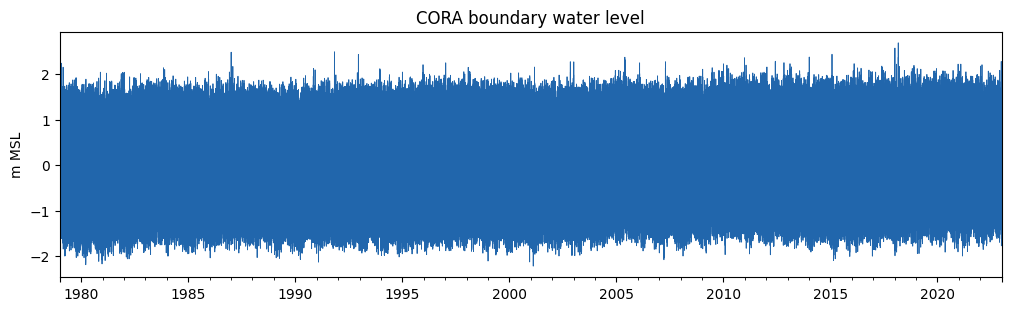

In [12]:
# Plot the collected CORA boundary water level.
waterlevel = _read_csv(paths["waterlevel_csv"], parse_dates=["time"])

if not waterlevel.empty:
    value_column = _first_column(waterlevel, ["value", "zeta", "water_level", "waterlevel"])
    fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
    waterlevel.set_index("time")[value_column].plot(ax=ax, color="#2166ac", linewidth=0.6)
    ax.set_title("CORA boundary water level")
    ax.set_xlabel("")
    ax.set_ylabel("m MSL")
    plt.show()


### NWM Soil Moisture

Soil moisture is summarized across configured NWM points and layers.


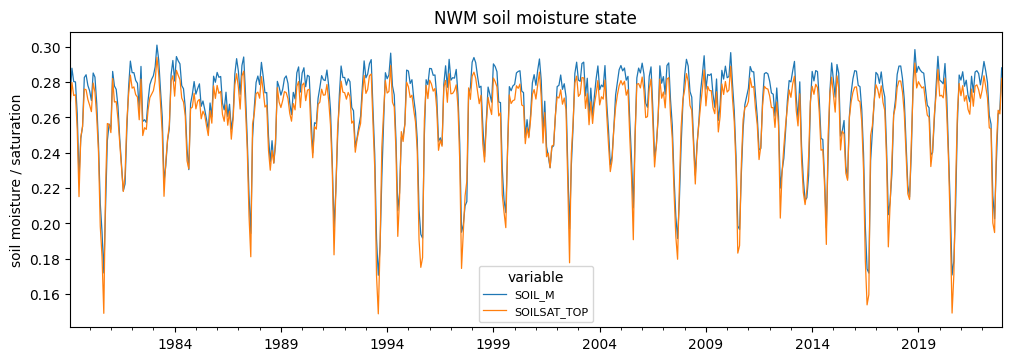

requested_variables                                [SOIL_M, SOILSAT_TOP]
available_variables                                [SOIL_M, SOILSAT_TOP]
missing_variables                                                     []
csv                    /home/grahamhults/projects/Flood-RM/locations/...
Name: nwm_soil_moisture_status, dtype: object

In [13]:
# Plot monthly mean NWM soil moisture variables when available.
soil_moisture = _read_csv(paths["nwm_soil_moisture_csv"], parse_dates=["time"])
requested_soil_variables = list(config["collection"].get("nwm", {}).get("soil_moisture", {}).get("variables", []))
available_soil_variables = [name for name in requested_soil_variables if name in soil_moisture.columns]
legacy_soil_variable = _first_column(soil_moisture, ["SOIL_M", "soil_m", "soil_moisture"])
if legacy_soil_variable and legacy_soil_variable not in available_soil_variables:
    available_soil_variables.append(legacy_soil_variable)
missing_soil_variables = [name for name in requested_soil_variables if name not in soil_moisture.columns]

if not soil_moisture.empty and available_soil_variables:
    monthly = (
        soil_moisture.groupby("time")[available_soil_variables]
        .mean()
        .resample("MS")
        .mean()
    )
    fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
    monthly.plot(ax=ax, linewidth=0.9)
    ax.set_title("NWM soil moisture state")
    ax.set_xlabel("")
    ax.set_ylabel("soil moisture / saturation")
    ax.legend(title="variable", loc="best", fontsize=8)
    plt.show()

    display(pd.Series({
        "requested_variables": requested_soil_variables,
        "available_variables": available_soil_variables,
        "missing_variables": missing_soil_variables,
        "csv": str(paths["nwm_soil_moisture_csv"]),
    }, name="nwm_soil_moisture_status"))
elif paths["nwm_soil_moisture_csv"].exists():
    display(pd.Series({
        "requested_variables": requested_soil_variables,
        "available_variables": available_soil_variables,
        "missing_variables": missing_soil_variables,
        "csv": str(paths["nwm_soil_moisture_csv"]),
    }, name="nwm_soil_moisture_status"))


### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


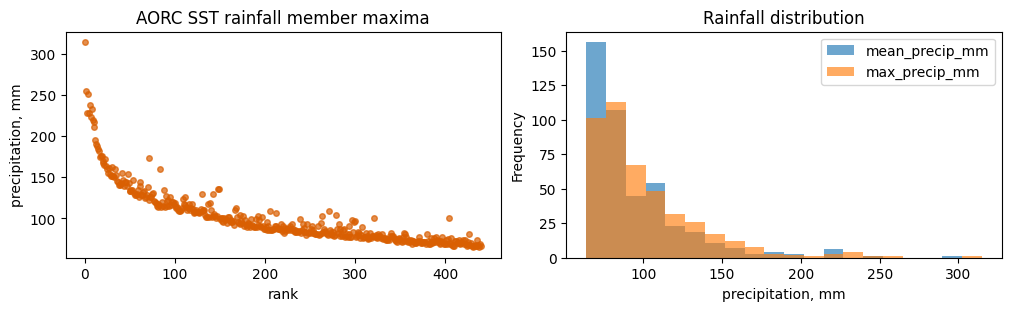

In [14]:
# Plot compact AORC SST rainfall member summaries.
rainfall = _read_csv(paths["aorc_sst_rainfall_members_csv"], parse_dates=["storm_start", "storm_end"])

if not rainfall.empty:
    max_column = _first_column(rainfall, ["max_precip_mm", "max_precip_in", "max"])
    mean_column = _first_column(rainfall, ["mean_precip_mm", "mean_precip_in", "mean"])
    if max_column is None or mean_column is None:
        raise KeyError("rainfall members need max and mean precipitation columns")
    unit = "mm"
    if "precip_units" in rainfall and rainfall["precip_units"].notna().any():
        unit = str(rainfall["precip_units"].dropna().iloc[0])
    elif str(max_column).endswith("_in"):
        unit = "in"
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    rainfall.plot.scatter(x="rank", y=max_column, ax=axes[0], color="#d95f02", s=16, alpha=0.7)
    axes[0].set_title("AORC SST rainfall member maxima")
    axes[0].set_xlabel("rank")
    axes[0].set_ylabel(f"precipitation, {unit}")
    rainfall[[mean_column, max_column]].plot.hist(ax=axes[1], bins=20, alpha=0.65)
    axes[1].set_title("Rainfall distribution")
    axes[1].set_xlabel(f"precipitation, {unit}")
    plt.show()


### ERA5 Wave Forcing

Wave variables are reduced to monthly spatial means for a compact quality check.


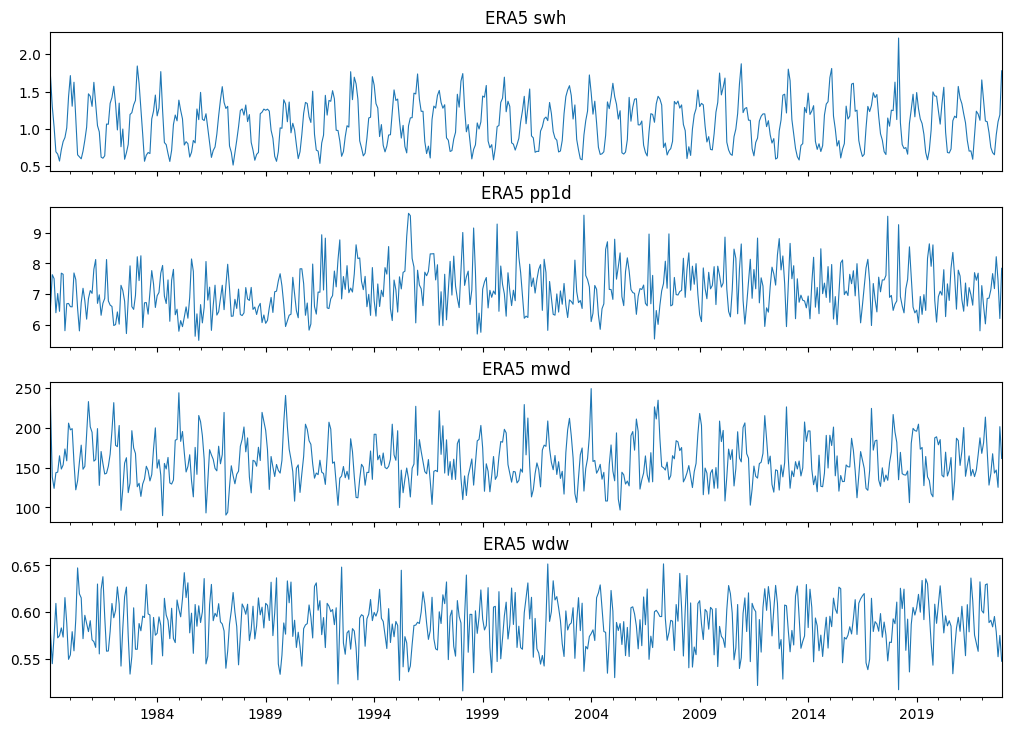

In [15]:
# Plot compact ERA5 wave time series when available.
import xarray as xr

wave_path = Path(paths["era5_waves_nc"])

if wave_path.exists():
    with xr.open_dataset(wave_path) as ds:
        time_name = _first_column(pd.DataFrame(columns=list(ds.coords) + list(ds.dims)), ["valid_time", "time"])
        wave_vars = [name for name in ["swh", "pp1d", "mwd", "wdw"] if name in ds.data_vars]
        fig, axes = plt.subplots(len(wave_vars), 1, figsize=(10, 1.8 * len(wave_vars)), sharex=True, constrained_layout=True)
        axes = [axes] if len(wave_vars) == 1 else axes

        for ax, name in zip(axes, wave_vars):
            spatial_dims = [dim for dim in ds[name].dims if dim != time_name]
            series = ds[name].mean(dim=spatial_dims).resample({time_name: "MS"}).mean()
            series.to_pandas().plot(ax=ax, linewidth=0.8)
            ax.set_title(f"ERA5 {name}")
            ax.set_xlabel("")
        plt.show()
